# TransferBench

# Final Benchmark Report

This notebook compares all transfer learning experiments.

Included Models

- ResNet18 Feature Extraction
- ResNet18 Fine-Tuning
- EfficientNet-B0 Feature Extraction
- EfficientNet-B0 Fine-Tuning
- Vision Transformer Feature Extraction
- Vision Transformer Fine-Tuning

Outputs

- Comparison Table
- Accuracy Ranking
- Training Time Ranking
- Radar Chart
- Bar Charts
- Final Markdown Report

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\pc1\TransferBench


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

from utils.paths import *

Import OK ✅


## Load All Metrics

In [3]:
csv_files = sorted(

    Path(RESULT_DIR).glob("*metrics*.csv")

)

csv_files

[WindowsPath('C:/Users/pc1/TransferBench/results/efficientnet_finetune_metrics.csv'),
 WindowsPath('C:/Users/pc1/TransferBench/results/efficientnet_freeze_metrics.csv'),
 WindowsPath('C:/Users/pc1/TransferBench/results/resnet18_finetune_metrics.csv'),
 WindowsPath('C:/Users/pc1/TransferBench/results/resnet18_metrics.csv'),
 WindowsPath('C:/Users/pc1/TransferBench/results/vit_finetune_metrics.csv'),
 WindowsPath('C:/Users/pc1/TransferBench/results/vit_freeze_metrics.csv')]

In [4]:
tables = []

for file in csv_files:

    df = pd.read_csv(file)

    df["Experiment"] = file.stem

    tables.append(df)

benchmark = pd.concat(
    tables,
    ignore_index=True
)

benchmark

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Experiment,F1
0,EfficientNet-B0,Fine-Tuning,0.8905,0.891752,0.8905,0.890035,1525.123615,efficientnet_finetune_metrics,NaN
1,EfficientNet-B0,Feature Extraction,0.8354,0.835958,0.8354,0.834041,3464.282269,efficientnet_freeze_metrics,NaN
2,ResNet18,Fine-Tuning,0.9399,0.940089,0.9399,0.939756,1634.346132,resnet18_finetune_metrics,NaN
3,ResNet18,Freeze Feature Extractor,0.7887,0.794424,0.7887,NaN,435.569929,resnet18_metrics,0.788154
4,ViT-B16,Fine-Tuning,0.9693,0.969445,0.9693,0.969322,11270.475773,vit_finetune_metrics,NaN
5,ViT-B16,Feature Extraction,0.9557,0.955738,0.9557,0.955679,10165.475193,vit_freeze_metrics,NaN


## Save Benchmark Table

In [5]:
benchmark.to_csv(

    Path(RESULT_DIR) /
    "benchmark_results.csv",

    index=False

)

benchmark

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Experiment,F1
0,EfficientNet-B0,Fine-Tuning,0.8905,0.891752,0.8905,0.890035,1525.123615,efficientnet_finetune_metrics,NaN
1,EfficientNet-B0,Feature Extraction,0.8354,0.835958,0.8354,0.834041,3464.282269,efficientnet_freeze_metrics,NaN
2,ResNet18,Fine-Tuning,0.9399,0.940089,0.9399,0.939756,1634.346132,resnet18_finetune_metrics,NaN
3,ResNet18,Freeze Feature Extractor,0.7887,0.794424,0.7887,NaN,435.569929,resnet18_metrics,0.788154
4,ViT-B16,Fine-Tuning,0.9693,0.969445,0.9693,0.969322,11270.475773,vit_finetune_metrics,NaN
5,ViT-B16,Feature Extraction,0.9557,0.955738,0.9557,0.955679,10165.475193,vit_freeze_metrics,NaN


## Accuracy Ranking

In [6]:
ranking = benchmark.sort_values(

    "Accuracy",

    ascending=False,

)

ranking

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Experiment,F1
4,ViT-B16,Fine-Tuning,0.9693,0.969445,0.9693,0.969322,11270.475773,vit_finetune_metrics,NaN
5,ViT-B16,Feature Extraction,0.9557,0.955738,0.9557,0.955679,10165.475193,vit_freeze_metrics,NaN
2,ResNet18,Fine-Tuning,0.9399,0.940089,0.9399,0.939756,1634.346132,resnet18_finetune_metrics,NaN
0,EfficientNet-B0,Fine-Tuning,0.8905,0.891752,0.8905,0.890035,1525.123615,efficientnet_finetune_metrics,NaN
1,EfficientNet-B0,Feature Extraction,0.8354,0.835958,0.8354,0.834041,3464.282269,efficientnet_freeze_metrics,NaN
3,ResNet18,Freeze Feature Extractor,0.7887,0.794424,0.7887,NaN,435.569929,resnet18_metrics,0.788154


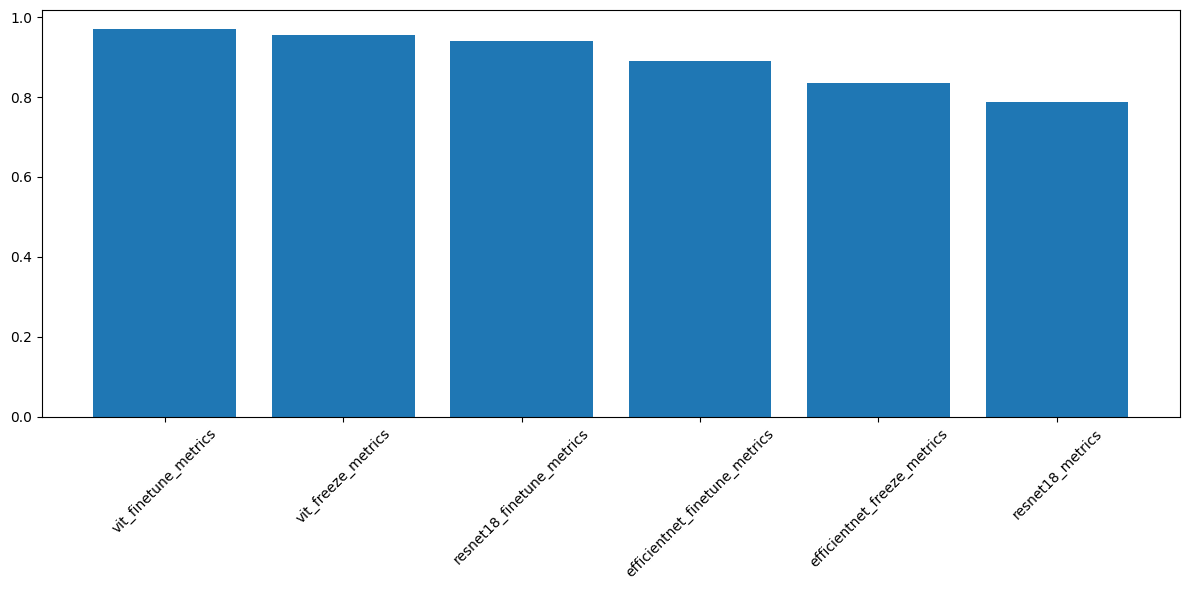

In [7]:
plt.figure(figsize=(12,6))

plt.bar(

    ranking["Experiment"],

    ranking["Accuracy"]

)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(

    Path(FIGURE_DIR) /

    "accuracy_ranking.png"

)

plt.show()

## F1 Score Ranking

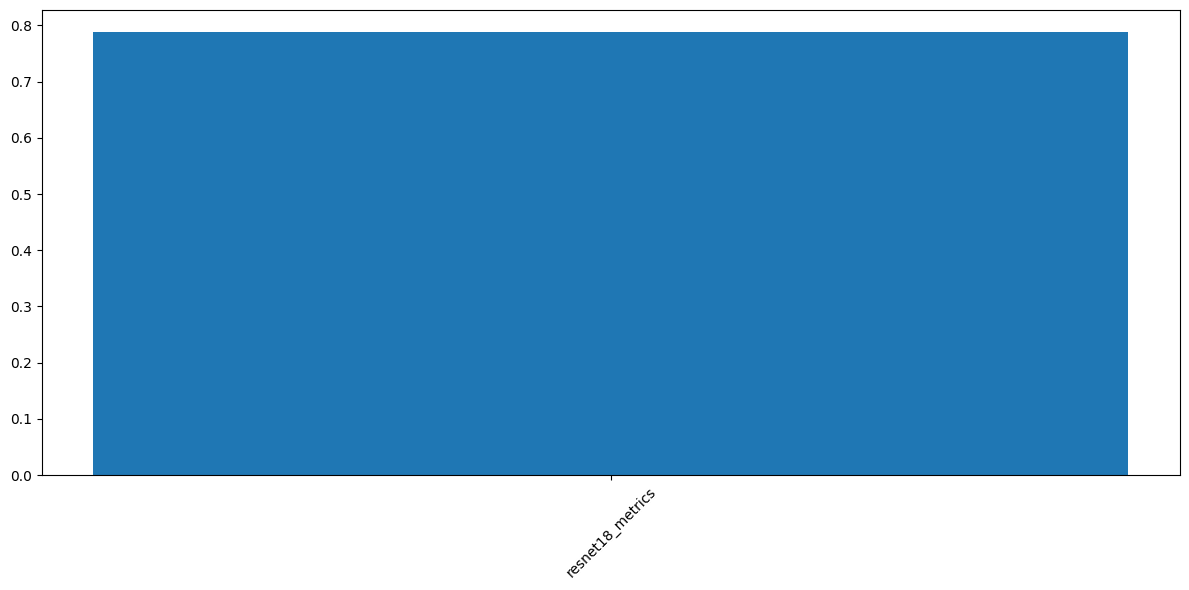

In [9]:
ranking = benchmark.sort_values(

    "F1",

    ascending=False

)

plt.figure(figsize=(12,6))

plt.bar(

    ranking["Experiment"],

    ranking["F1"]

)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(

    Path(FIGURE_DIR) /

    "f1_ranking.png"

)

plt.show()

## Training Time

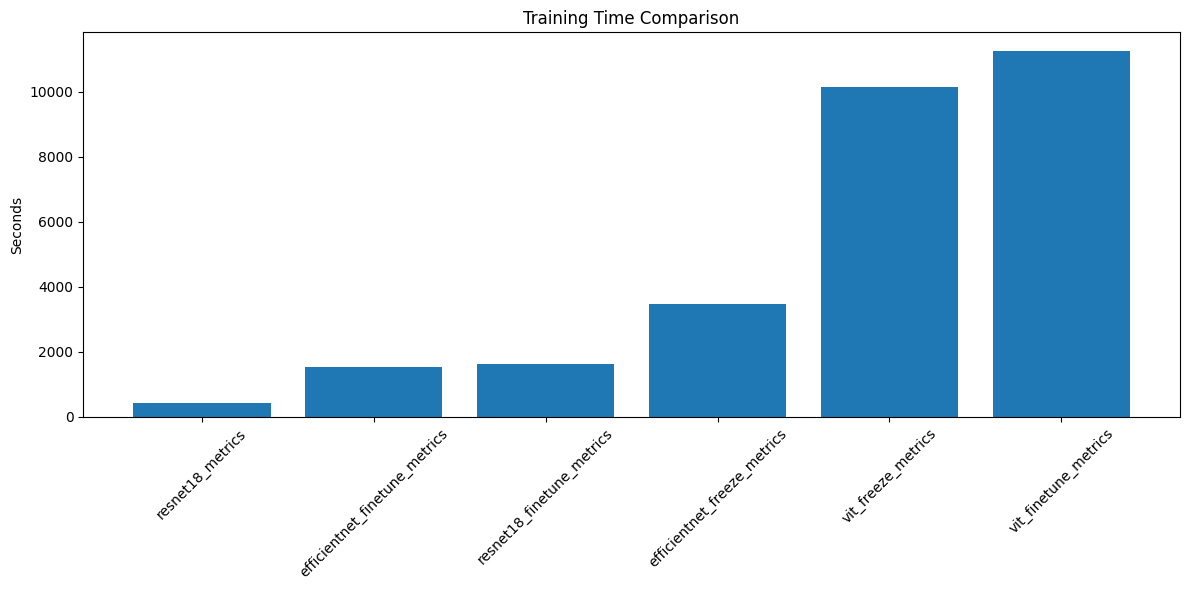

In [12]:
ranking = benchmark.sort_values(
    "Training Time (sec)"
)

plt.figure(figsize=(12,6))

plt.bar(
    ranking["Experiment"],
    ranking["Training Time (sec)"]
)

plt.title("Training Time Comparison")

plt.ylabel("Seconds")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    Path(FIGURE_DIR) /
    "training_time.png"
)

plt.show()

## Radar Chart

In [13]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

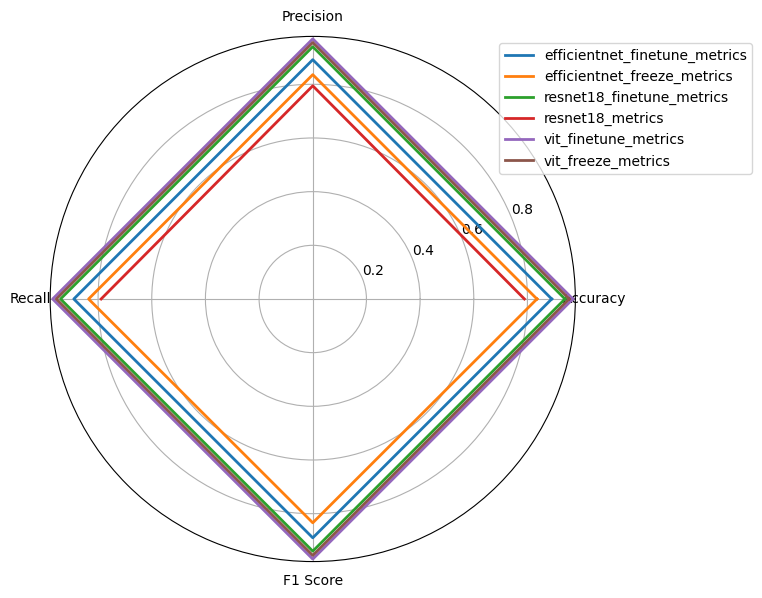

In [14]:
angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
)

angles = np.concatenate(
    [angles,[angles[0]]]
)

plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

for _, row in benchmark.iterrows():

    values = [
        row[m]
        for m in metrics
    ]

    values.append(values[0])

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Experiment"]
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(metrics)

plt.legend(
    bbox_to_anchor=(1.35,1)
)

plt.tight_layout()

plt.savefig(
    Path(FIGURE_DIR) /
    "benchmark_radar.png"
)

plt.show()

In [15]:
best = benchmark.loc[
    benchmark["Accuracy"].idxmax()
]

best

Model                               ViT-B16
Strategy                        Fine-Tuning
Accuracy                             0.9693
Precision                          0.969445
Recall                               0.9693
F1 Score                           0.969322
Training Time (sec)            11270.475773
Experiment             vit_finetune_metrics
F1                                      NaN
Name: 4, dtype: object

In [20]:
report = f"""
# TransferBench Benchmark Report

## Best Performing Model

Model: {best["Model"]}

Strategy: {best["Strategy"]}

Accuracy: {best["Accuracy"]:.4f}

Precision: {best["Precision"]:.4f}

Recall: {best["Recall"]:.4f}

F1 Score: {best["F1 Score"]:.4f}

Training Time: {best["Training Time (sec)"]:.2f} sec

---

## Complete Benchmark

{benchmark.to_markdown(index=False)}

"""

In [21]:
print(report)


# TransferBench Benchmark Report

## Best Performing Model

Model: ViT-B16

Strategy: Fine-Tuning

Accuracy: 0.9693

Precision: 0.9694

Recall: 0.9693

F1 Score: 0.9693

Training Time: 11270.48 sec

---

## Complete Benchmark

| Model           | Strategy                 |   Accuracy |   Precision |   Recall |   F1 Score |   Training Time (sec) | Experiment                    |         F1 |
|:----------------|:-------------------------|-----------:|------------:|---------:|-----------:|----------------------:|:------------------------------|-----------:|
| EfficientNet-B0 | Fine-Tuning              |     0.8905 |    0.891752 |   0.8905 |   0.890035 |               1525.12 | efficientnet_finetune_metrics | nan        |
| EfficientNet-B0 | Feature Extraction       |     0.8354 |    0.835958 |   0.8354 |   0.834041 |               3464.28 | efficientnet_freeze_metrics   | nan        |
| ResNet18        | Fine-Tuning              |     0.9399 |    0.940089 |   0.9399 |   0.939756 |       

In [22]:
with open(
    Path(RESULT_DIR) /
    "benchmark_report.md",
    "w",
    encoding="utf8"
) as f:

    f.write(report)

In [23]:
benchmark.to_csv(
    Path(RESULT_DIR) /
    "benchmark_results.csv",
    index=False
)

In [24]:
print("=" * 80)

print("Generated Figures")

for file in sorted(Path(FIGURE_DIR).glob("*")):
    print(file.name)

print()

print("Generated Results")

for file in sorted(Path(RESULT_DIR).glob("*")):
    print(file.name)

print("=" * 80)

Generated Figures
.ipynb_checkpoints
accuracy_ranking.png
benchmark_radar.png
confusion_matrix_efficientnet_finetune.png
confusion_matrix_efficientnet_freeze.png
confusion_matrix_resnet18.png
confusion_matrix_resnet18_finetune.png
confusion_matrix_vit_finetune.png
confusion_matrix_vit_freeze.png
dataset_samples.png
efficientnet_finetune_accuracy.png
efficientnet_finetune_loss.png
efficientnet_freeze_accuracy.png
efficientnet_freeze_loss.png
f1_ranking.png
resnet18_accuracy.png
resnet18_finetune_accuracy.png
resnet18_finetune_loss.png
resnet18_loss.png
training_time.png
vit_finetune_accuracy.png
vit_finetune_loss.png
vit_freeze_accuracy.png
vit_freeze_loss.png

Generated Results
.ipynb_checkpoints
benchmark_report.md
benchmark_results.csv
efficientnet_finetune_metrics.csv
efficientnet_freeze_metrics.csv
resnet18_finetune_metrics.csv
resnet18_metrics.csv
vit_finetune_metrics.csv
vit_freeze_metrics.csv


In [25]:
print("TransferBench Benchmark Completed Successfully")

print()

print(f"Best Model : {best['Model']}")

print(f"Strategy   : {best['Strategy']}")

print(f"Accuracy   : {best['Accuracy']:.4f}")

print()

print("Benchmark report generated.")

print("Benchmark CSV saved.")

print("All charts generated.")

TransferBench Benchmark Completed Successfully

Best Model : ViT-B16
Strategy   : Fine-Tuning
Accuracy   : 0.9693

Benchmark report generated.
Benchmark CSV saved.
All charts generated.
